In [1]:
from optimization import *

device = torch.device('cuda:0')

In [40]:
config = OptimizationConfig(
    n_batch=10,
    min_steps=1000,
    max_steps=2000,
    sa_steps=2000,
    seq_length=100,
    alt_start_pos=50    
)

#Random AA for testing
fix_aa = F.one_hot(torch.randint(20, (1, 50//3 - 1)), 21).transpose(2, 1).to(torch.float32).to(config.device).repeat(config.n_batch, 1, 1) 
right_overhang_mask = F.one_hot(torch.randint(4, (1, 2)), 4).transpose(2, 1).to(torch.bool).to(config.device).repeat(config.n_batch, 1, 1)

print(''.join([ AA_ALPHABET[i] for i in fix_aa[0].argmax(0) ]))
print(''.join([ DNA_ALPHABET[i] for i in right_overhang_mask[0].float().argmax(0) ]))

AEDQSFDQEYQCFCV
CA


In [41]:
# Create and run pipeline
pipeline = OptimusOLGPipeline(config)
result = pipeline.run(fix_aa, right_overhang_mask)

Starting gradient-based optimization...
Starting simulated annealing with 10 sequences...
Optimization complete. Found 10 optimized sequences.


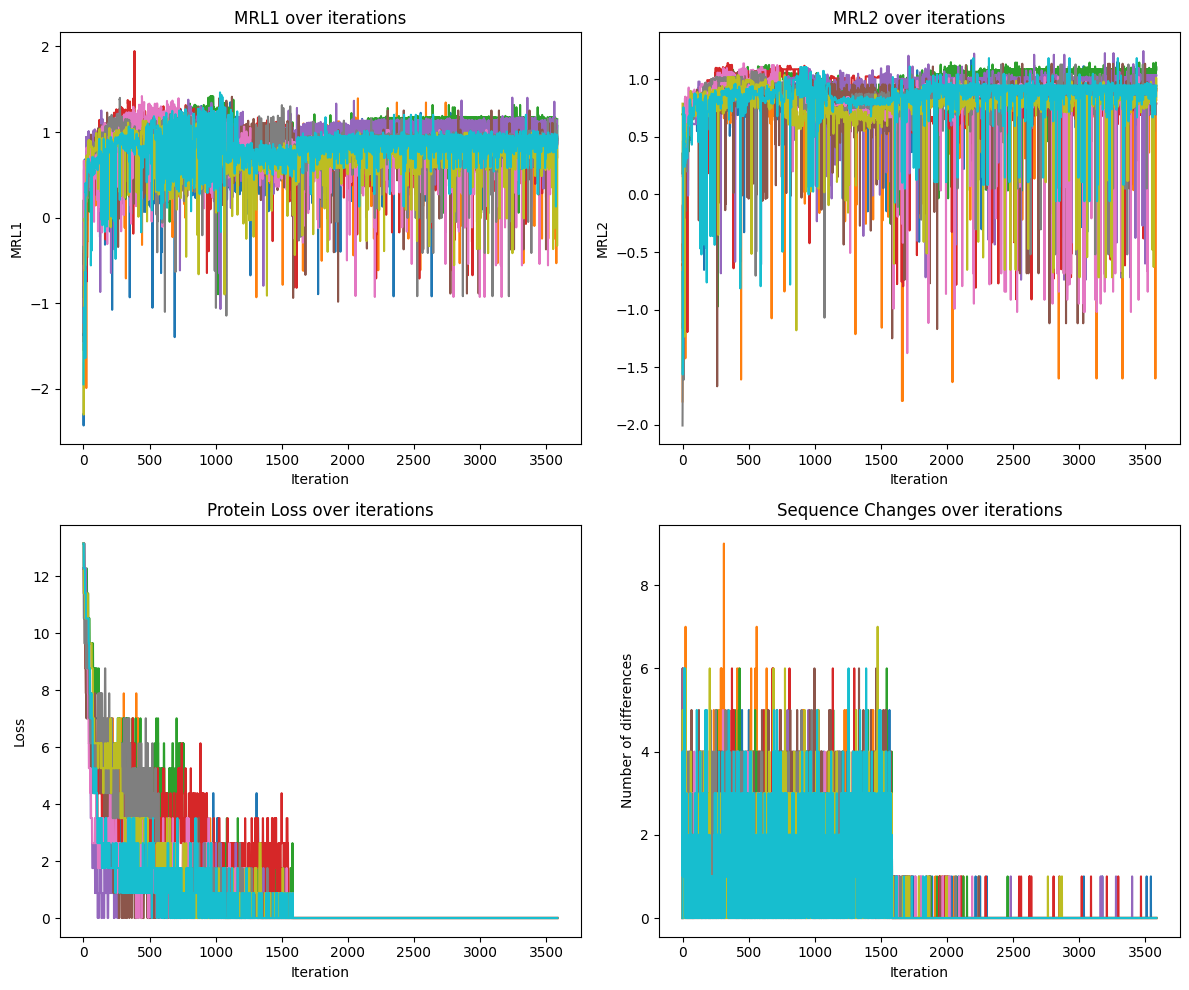

In [42]:
pipeline.plot_results(result)

In [51]:
torch.stack([ torch.stack([r[1], r[2]]) for r in result.best_results ])

tensor([[1.1127, 0.9255],
        [0.9471, 0.8227],
        [1.1738, 1.0862],
        [0.8760, 0.7912],
        [1.1192, 1.0361],
        [0.9264, 0.9447],
        [0.8976, 0.9064],
        [0.9670, 0.9111],
        [0.8822, 0.8423],
        [0.9511, 0.9457]], device='cuda:0')

In [50]:
[ ''.join([ DNA_ALPHABET[c] for c in r[0].argmax(0) ]) for r in result.best_results ]

['AGGGAAAAATTAACCTGTCTGTTGTCCCTTTGTCTCTGCGGTTTCGTTTAATGGCCGAAGATCAGTCCTTCGATCAGGAATACCAATGCTTCTGTGTACA',
 'TATATCAGATAGGGAGGCAAAACCTAGTCCCTTAACTTAGTTTTCGTTCCATGGCAGAAGATCAGTCTTTCGATCAGGAATACCAATGCTTCTGTGTACA',
 'TTCTAGCTTCGTTTGTCCCTTTAGTCCCTTAGAACCTAGCTGATTAACCCATGGCCGAAGATCAGTCCTTCGATCAGGAATACCAATGCTTCTGTGTACA',
 'GCATTGCGGATAGCTTTTCTCTAGTCCTTCTGTTGGTTTGATTGTCTCGCATGGCAGAAGATCAGTCCTTCGATCAAGAGTATCAGTGTTTCTGTGTGCA',
 'TCCCGTTGATTATTGTCCCTTTTGTCTAGTTCCCAATTGGATAGCGTTTAATGGCCGAAGATCAGTCCTTCGATCAGGAATACCAATGCTTCTGTGTACA',
 'AAGTTCGCCCTCTGACACATTTCGATAGAGTATAAACTAGTGACTAGTCCATGGCCGAAGATCAGTCTTTCGATCAGGAATACCAATGCTTCTGTGTACA',
 'GGGAAGGGAAAATTGATAGAGAGAGGAGTATTTGAATAGCTTAATCCCGCATGGCAGAAGATCAGTCCTTCGATCAAGAATATCAGTGTTTCTGTGTGCA',
 'GCAGACGAGGAGATAAAAAAATAGAACAGATTTCGATAGTTGCACATTTAATGGCCGAAGATCAGTCCTTCGATCAGGAATACCAATGCTTCTGTGTACA',
 'GAATAGACAAGTTAACGTTCGTCTAATAGGTGTGCGTAGTTTTAAACCGCATGGCAGAAGATCAGTCTTTCGATCAGGAATACCAATGCTTCTGTGTACA',
 'TAACTTAATCCCTGATAGATAGTTTCCCCTGTGTGAATAGTTTTCGTTTAATG